In [1]:
import pandas as pd
df = pd.read_csv('amazon_delivery.csv')

In [2]:
df = df.drop(['Order_ID', 'Pickup_Time'], axis=1)

In [3]:
import datetime as dt

df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['day_of_week'] = df['Order_Date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['month'] = df['Order_Date'].dt.month

df['Order_Time'] = pd.to_datetime(df['Order_Time'], format= '%H:%M:%S', errors='coerce')

df['hour'] = df['Order_Time'].dt.hour

df['order_hour_block'] = pd.cut(df['hour'], bins=[0, 6, 12, 18, 24], labels=('night', 'morning', 'afternoon', 'evening'))

df['is_fast_delivery'] = (df['Delivery_Time'] >= df['Delivery_Time'].median()).astype(int) 

In [4]:
df.groupby('is_fast_delivery')['Agent_Rating'].mean()

is_fast_delivery
0    4.719898
1    4.551695
Name: Agent_Rating, dtype: float64

## The columns 'Order_Date', and 'Date_time' served their purpose. Having successfuly extracted the needed information from those columns, I can drop them without hesitation.

In [5]:
df = df.drop(['Order_Date', 'Order_Time', 'hour', 'Delivery_Time'], axis=1)

In [6]:
df.head()

,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Weather,Traffic,Vehicle,Area,Category,day_of_week,is_weekend,month,order_hour_block,is_fast_delivery
0,37,4.9,22.745049,75.892471,22.765049,75.912471,Sunny,High,motorcycle,Urban,Clothing,5,1,3,morning,0
1,34,4.5,12.913041,77.683237,13.043041,77.813237,Stormy,Jam,scooter,Metropolitian,Electronics,4,0,3,evening,1
2,23,4.4,12.914264,77.678400,12.924264,77.688400,Sandstorms,Low,motorcycle,Urban,Sports,5,1,3,morning,1
3,38,4.7,11.003669,76.976494,11.053669,77.026494,Sunny,Medium,motorcycle,Metropolitian,Cosmetics,1,0,4,afternoon,0
4,32,4.6,12.972793,80.249982,13.012793,80.289982,Cloudy,High,scooter,Metropolitian,Toys,5,1,3,afternoon,1


In [7]:
df.nunique()

Agent_Age             22
Agent_Rating          28
Store_Latitude       521
Store_Longitude      415
Drop_Latitude       4367
Drop_Longitude      4367
Weather                6
Traffic                5
Vehicle                4
Area                   4
Category              16
day_of_week            7
is_weekend             2
month                  3
order_hour_block       3
is_fast_delivery       2
dtype: int64

In [8]:
onehot_cols =['Weather', 'Traffic', 'Vehicle', 'Area', 'order_hour_block']
target_cols = ['Category']
num_cols = ['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'day_of_week', 'is_weekend', 'month']
df.shape

(43739, 16)

In [9]:
print(set(df.drop('is_fast_delivery', axis=1).columns) - set(num_cols) - set(onehot_cols) - set(target_cols))

{'Drop_Longitude', 'Drop_Latitude'}


In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fast_delivery', axis=1)
y = df['is_fast_delivery']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

num_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_preprocessor, num_cols),
    ('onehot', OneHotEncoder(), onehot_cols), 
    ('target', TargetEncoder(), target_cols)
], remainder='passthrough')

xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', XGBClassifier(reg_lambda=2, reg_alpha=0, max_depth=3, learning_rate=0.1, n_jobs=-1, random_state=42))
])

xgb_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

params = {
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],  
    'model__reg_lambda': [0, 2, 3, 5], 
    'model__reg_alpha': [0, 2, 3, 5], 
    'model__max_depth': [3, 5, 7], 
    'preprocessor__target__smooth': [0.1, 1.0, 10.0, 50.0]
}
xgb_search = HalvingRandomSearchCV(
    estimator=xgb_pipe,cv=5,verbose=1, param_distributions=params, 
)
xgb_search.fit(X_train, y_train)

n_iterations: 7
n_required_iterations: 7
n_possible_iterations: 7
min_resources_: 20
max_resources_: 34991
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 768
n_resources: 20
Fitting 5 folds for each of 768 candidates, totalling 3840 fits


C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 768 is smaller than n_iter=1749. Running 768 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "C:

----------
iter: 2
n_candidates: 86
n_resources: 180
Fitting 5 folds for each of 86 candidates, totalling 430 fits


C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\utils\_set_output.py", line 316, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
  File "C:\Users\FILD\streamlit\env\Lib\site-packages\sklearn\compose\_column_transformer.py", line 109

In [20]:
print(xgb_search.best_params_)

{'preprocessor__target__smooth': 10.0, 'model__reg_lambda': 3, 'model__reg_alpha': 5, 'model__max_depth': 7, 'model__learning_rate': 0.1}


In [21]:
best_model = xgb_search.best_estimator_

best_model_train_score = xgb_search.score(X_train, y_train)
best_model_test_score = xgb_search.score(X_test, y_test)
 
print(f'train score: {best_model_train_score}')
print(f'test score: {best_model_test_score}')

train score: 0.8462747563659226
test score: 0.8238454503886603


In [22]:
best_model_pred = best_model.predict_proba(X_test)
y_proba = best_model_pred[:, 1]
y_proba = (y_proba >= 0.5).astype(int)


In [23]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_proba))
print(confusion_matrix(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      4269
           1       0.85      0.80      0.82      4479

    accuracy                           0.82      8748
   macro avg       0.82      0.82      0.82      8748
weighted avg       0.83      0.82      0.82      8748

[[3619  650]
 [ 891 3588]]


In [24]:
y_proba_04 = (y_proba >= 0.4).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(classification_report(y_test, y_proba_04))
print(confusion_matrix(y_test, y_proba_04))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82      4269
           1       0.85      0.80      0.82      4479

    accuracy                           0.82      8748
   macro avg       0.82      0.82      0.82      8748
weighted avg       0.83      0.82      0.82      8748

[[3619  650]
 [ 891 3588]]


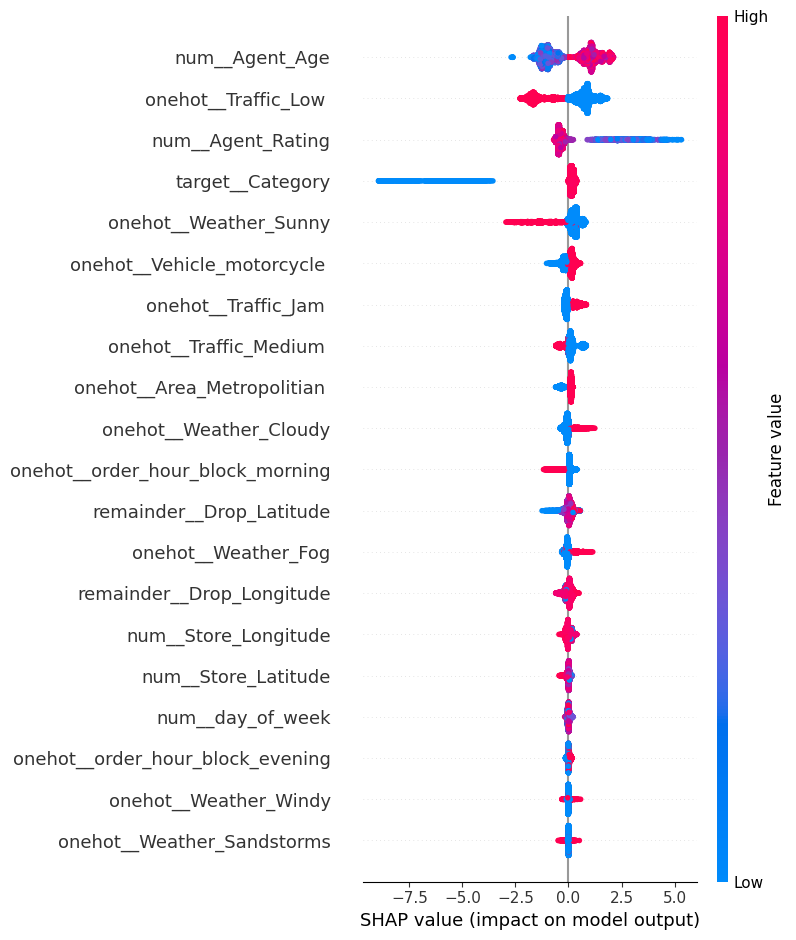

In [25]:
from shap import TreeExplainer, summary_plot
import joblib as jl 
extracted_model = best_model.named_steps['model']
X_test_prepped = best_model.named_steps['preprocessor'].transform(X_test)
feature_names = preprocessor.get_feature_names_out()

explainer = TreeExplainer(extracted_model)
shap_values = explainer.shap_values(X_test_prepped)

# Saving the two necessary variables using joblib:
#jl.dump(X_test_prepped, 'X_test_prepped.pkl')
#jl.dump(feature_names, 'feature_names.pkl')
summary_plot(shap_values, X_test_prepped, feature_names=feature_names)

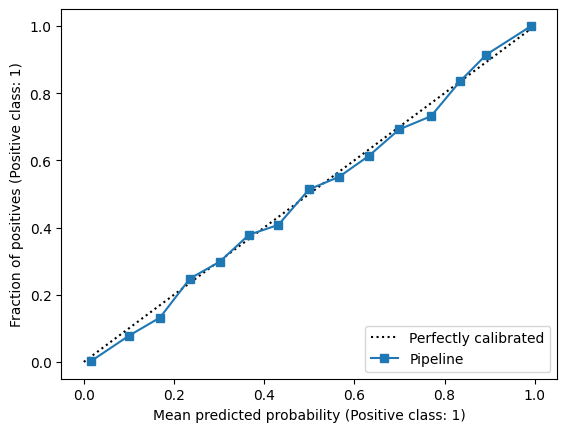

In [26]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt 
disp = CalibrationDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    n_bins=15
)

plt.show()

# Delivery Prediction Model: Performance & Financial Analysis

**Dataset:** Amazon Delivery Performance (Binary Classification)  
**Target Variable:** Fast Delivery = 1 (Positive), Slow Delivery = 0 (Negative)  
**Model Matrix Counts:** 650 False Positives | 891 False Negatives  

This analysis evaluates the financial impact of my delivery speed prediction model. By converting standard machine learning classification errors into concrete operational costs, I can determine whether the model's current threshold is financially optimized.

---

## 1. Defining the Core Errors

Because my model uses **Fast Delivery as the Positive Class (1)**, the prediction errors break down into two distinct business scenarios:

* **False Positives (650 cases): Over-Promising**
    * *What happened:* The model predicts a **Fast** delivery, but the package actually arrives **Slow**.
    * *The Reality:* The user is promised a fast delivery and it gets missed, leading to complaints, support tickets, or potential cancellations.
* **False Negatives (891 cases): Under-Promising**
    * *What happened:* The model predicts a **Slow** delivery, but the package actually arrives **Fast**.
    * *The Reality:* The system acts as if a package will be late and triggers an automated apology/promo credit (\$5 value) to smooth things over, but since the package actually arrived on time, that budget is wasted.

---

## 2. Cost Matrix Framework & Assumptions

To calculate total financial risk, I am assigning realistic operational weights ($C_{FP}$ and $C_{FN}$) to each error type based on standard retail support data.

### Cost of a False Positive ($C_{FP}$) = \$25
Over-promising and under-delivering forces reactive costs. Handling customer service complaints, processing shipping refunds, and managing the loss of user trust costs roughly **\$25 per occurrence**.

### Cost of a False Negative ($C_{FN}$) = \$5
Under-promising means sending an unnecessary proactive \$5 credit to a customer whose package actually arrived fast. This results in a direct loss of **\$5 per occurrence**.

---

## 3. Financial Impact Calculation

Using the standard Cost Matrix formula to calculate the total drain on margins:

$$\text{Total Financial Cost} = (\text{FP} \times C_{FP}) + (\text{FN} \times C_{FN})$$

Plugging in my specific matrix metrics:

$$\text{Total Financial Cost} = (650 \times \$25) + (891 \times \$5)$$

$$\text{Total Financial Cost} = \$16,250 + \$4,455 = \mathbf{\$20,705}$$

### Financial Split:
* **Over-Promising Cost (False Positives):** \$16,250 *(78.5% of total loss)*
* **Wasted Marketing Budget (False Negatives):** \$4,455 *(21.5% of total loss)*

---

## 4. Key Insights & Conclusion

Even though this model yields *fewer* False Positives (650) than False Negatives (891), **False Positives drive nearly 80% of the total financial loss.** Breaking a delivery promise costs five times more per incident than giving away a wasted promotional credit.

### Next Step:
To optimize this, I need to adjust the decision threshold of the classification model. Shifting the threshold to be more conservative will force the model to predict "Slow" unless it is highly confident the delivery will be fast. While this will increase the number of False Negatives (wasted \$5 credits), it will significantly drop the False Positives (\$25 support issues), reducing the total operational cost of running this model.